# 🐼 Les DataFrames pandas — cheat-sheet, tutoriel & wiki

Notebook de référence sur **pandas DataFrame** (recettes prêtes à copier + explications *quoi / pourquoi / quand*).

Mis à jour **2026** : code écrit pour l'env installé (**pandas 2.3 / numpy 2.x**) tout en restant **compatible pandas 3.0** (sorti le 21/01/2026 : `str` dtype par défaut, *Copy-on-Write* par défaut). Concrètement on évite l'assignation chaînée, on utilise `.ffill()/.bfill()` (plus `fillna(method=)`), `np.nan` (plus `np.NaN`), `aggfunc="mean"`, et on ne mute plus via `inplace=` les API qui l'ont retiré.

Dataset fil rouge : **Titanic** (`seaborn.load_dataset`, chargement programmatique). Couverture : création/chargement, inspection, indexation, comptages, types, données manquantes, vectorisation, groupby, fusions (concat / merge / merge_asof / anti-join / update), apply, recherche conditionnelle, pivot/reshape, regex, affichage, et **Polars** en alternative.

Imports et options d'affichage (à exécuter en premier).

In [ ]:
from __future__ import annotations

import re
import tempfile
import time
from pathlib import Path

import numpy as np
import pandas as pd
import seaborn as sns

pd.options.display.max_columns = 50      # None -> aucune restriction
pd.options.display.max_rows = 200        # prudence sur gros DataFrames
pd.options.display.max_colwidth = 100
pd.options.display.precision = 3

print("pandas", pd.__version__, "| numpy", np.__version__)

## 1. Création & chargement

Un DataFrame se construit depuis un **dict de colonnes**, une **liste de records** (lignes), des arrays NumPy, etc.

In [ ]:
# Depuis un dict de colonnes
df_dict = pd.DataFrame({
    "name": ["Alice", "Bob", "Charlie"],
    "age": [30, 25, 35],
    "city": ["Paris", "Lyon", "Marseille"],
})
# Depuis une liste de records (lignes)
df_records = pd.DataFrame.from_records([
    {"name": "Alice", "age": 30},
    {"name": "Bob", "age": 25},
])
print(df_dict)
print(df_records)

Pour charger depuis un fichier, les *readers* pandas couvrent les formats usuels. Le **Parquet** (colonnaire, typé, compressé) est à préférer au CSV quand on maîtrise la source.

In [ ]:
# Snippets de chargement standard (commentés : pas de fichier ici).
# df = pd.read_csv("file.csv", parse_dates=["date"], dtype={"id": str})
# df = pd.read_parquet("file.parquet")               # colonnaire, + rapide que CSV
# df = pd.read_excel("file.xlsx", sheet_name=0)
# df = pd.read_json("file.json", lines=True)
# df = pd.read_sql("SELECT * FROM t", connection)
formats_io = ["csv", "parquet", "excel", "json", "sql"]   # ligne réelle (pas 100% commentaire)
print("readers pandas usuels:", formats_io)

Pour la suite on charge **Titanic** de façon programmatique (rien à committer, reproductible).

In [ ]:
df = sns.load_dataset("titanic")     # chargement programmatique, rien à committer
print(df.shape)

Quand un fichier **dépasse la RAM**, on lit par **morceaux** (`chunksize`) : `read_csv` renvoie alors un itérateur de DataFrames qu'on agrège au fur et à mesure (ici on recompose simplement le tout).

In [ ]:
# Pour un fichier trop gros pour la RAM : on agrège chunk par chunk.
with tempfile.TemporaryDirectory() as tmp:
    csv_path = Path(tmp) / "titanic.csv"
    df.to_csv(csv_path, index=False)
    chunksize = 200
    morceaux: list[pd.DataFrame] = []
    for i, chunk in enumerate(pd.read_csv(csv_path, chunksize=chunksize)):
        morceaux.append(chunk)
    df_concat = pd.concat(morceaux, ignore_index=True)
print(f"{i + 1} chunks -> {df_concat.shape[0]} lignes recomposées")

## 2. Informations sur le DataFrame

Premier réflexe : **regarder** les données. `head`/`tail`/`sample` donnent un aperçu (`sample` avec `random_state` pour la reproductibilité).

In [ ]:
print(df.head(3))      # premières lignes
print(df.tail(3))      # dernières lignes
print(df.sample(3, random_state=42))   # échantillon reproductible

Vue d'ensemble : `info` (types + non-null + mémoire), `describe` (stats numériques puis catégorielles), `memory_usage(deep=True)` pour la taille réelle (les `object`/strings comptent leur contenu).

In [ ]:
df.info()                                  # dtypes + non-null + mémoire
print("shape:", df.shape, "-> lignes:", df.shape[0], "colonnes:", df.shape[1])
print(df.describe())                       # stats numériques
print(df.describe(include="object"))       # stats catégorielles
print("mémoire (MB):", df.memory_usage(deep=True).sum() / 1e6)

Inspecter et **convertir les types**. Passer une colonne `object` à **faible cardinalité** en `category` économise beaucoup de mémoire et autorise un **ordre** sémantique.

In [ ]:
print(list(df.columns))
print(df.dtypes)
# Conversion de type
df["pclass"] = df["pclass"].astype("int64")
# Object faible cardinalité -> category (gain mémoire + ordre possible)
for col in df.select_dtypes(include="object").columns:
    if df[col].nunique() / len(df) < 0.05:
        df[col] = df[col].astype("category")
print(df.dtypes)

Suppression de colonnes par **nom** (`columns=`) ou par **position** (`df.columns[[...]]`).

In [ ]:
df_drop = df.drop(columns=["deck"])                      # par nom
df_drop = df.drop(df.columns[[0, 1]], axis=1)            # par position
print(df_drop.columns.tolist()[:5])

## 3. Indexation : `loc` / `iloc` / `[]` / `query`

Trois portes d'entrée :

- **`loc`** : par **label** (nom d'index / de colonne), bornes **incluses**.
- **`iloc`** : par **position** entière, borne supérieure **exclue** (comme les slices Python).
- **`[]`** : raccourci colonnes / masque booléen.

In [ ]:
sub_loc = df.loc[:, ["survived", "pclass"]]    # loc = labels
sub_iloc = df.iloc[:, 0:2]                     # iloc = positions (borne sup exclue)
print(sub_loc.head(1))
print(sub_iloc.head(1))
print(df.iloc[-3:].shape)                      # 3 dernières lignes

Le **masquage booléen** filtre les lignes. `.query("...")` offre une syntaxe SQL-like lisible ; `.isin([...])` teste l'appartenance ; `~` inverse un masque.

In [ ]:
m1 = df[df["age"] > 50]
m2 = df.query("age > 50 and sex == 'male'")    # syntaxe SQL-like
m3 = df[df["embarked"].isin(["S", "C"])]
m4 = df[~df["age"].isna()]
print(len(m1), len(m2), len(m3), len(m4))

Un **MultiIndex** (index hiérarchique) se sélectionne par **tuple** `df.loc[(niv1, niv2)]`. Toujours `sort_index()` avant un slicing partiel sur multi-index.

In [ ]:
mt = df.set_index(["pclass", "sex"]).sort_index()
print(mt.loc[(1, "female")].shape)             # sélection tuple multi-index
print(mt.loc[1].head(1))                       # premier niveau seul

## 4. Comptages

`value_counts(dropna=False)` compte les modalités **NaN compris** ; `unique` liste les valeurs distinctes ; `nunique` en donne le nombre.

In [ ]:
print(df["age"].value_counts(dropna=False).head())   # inclut les NaN
print(df["embarked"].unique())
print("modalités distinctes embarked:", df["embarked"].nunique())

## 5. Types & gestion des erreurs

`pd.to_numeric(..., errors="coerce")` transforme l'inconvertible en `NaN` — pratique pour **isoler les valeurs non numériques** d'une colonne sale. `pd.to_datetime(..., format=...)` parse les dates avec un format explicite (plus fiable et rapide que l'inférence).

In [ ]:
data_err = {
    "Date": ["01/26/2016 10:44:44", "02/15/2017 14:30:15", "07/02/2023 09:18:02"],
    "toto": ["1", np.nan, "abc"],
}
df_err = pd.DataFrame(data_err)
# Lignes NON numériques (coerce -> NaN sur ce qui n'est pas convertible)
print(df_err[pd.to_numeric(df_err["toto"], errors="coerce").isnull()])
# Lignes numériques
print(df_err[pd.to_numeric(df_err["toto"], errors="coerce").notnull()])
df_err["Date"] = pd.to_datetime(df_err["Date"], format="%m/%d/%Y %H:%M:%S")
print(df_err.dtypes)

## 6. Données manquantes

`ffill` propage la **dernière valeur connue** vers l'avant, `bfill` vers l'arrière, `limit=` borne le nombre de propagations. (En pandas 2.x, `fillna(method="ffill")` est déprécié au profit de `.ffill()`.)

In [ ]:
df_na = pd.DataFrame({"Val": [np.nan, 1, np.nan, np.nan, 2, np.nan, 3, 4, np.nan]})
df_na["ffill"] = df_na["Val"].ffill()              # propage en avant
df_na["bfill"] = df_na["Val"].bfill()              # propage en arrière
df_na["ffill_lim1"] = df_na["Val"].ffill(limit=1)  # max 1 propagation
print(df_na)

Panorama des stratégies : compter les NaN par colonne, **imputer** par médiane (numérique robuste) ou mode (catégoriel), **interpoler**, **supprimer** ciblé (`subset`) ou par seuil de complétude (`thresh`), et garder un **indicateur** « était NaN » (souvent informatif en modélisation).

In [ ]:
print(df.isna().sum().sort_values(ascending=False).head())   # NaN par colonne
age_med = df["age"].fillna(df["age"].median())               # imputation médiane
emb_mode = df["embarked"].fillna(df["embarked"].mode()[0])   # imputation mode
age_interp = df["age"].interpolate(method="linear")          # interpolation
df_dropna = df.dropna(subset=["age", "embarked"])            # drop ciblé
df_thresh = df.dropna(axis=1, thresh=int(len(df) * 0.5))     # cols >50% NaN
df_flag = df.assign(age_was_nan=df["age"].isna().astype(int))  # indicateur
print(age_med.isna().sum(), emb_mode.isna().sum(), age_interp.isna().sum(),
      df_dropna.shape, df_thresh.shape[1], df_flag["age_was_nan"].sum())

## 7. Vectorisation vs boucles

**Itérer en Python sur un DataFrame est lent.** Les opérations **vectorisées** (déléguées à NumPy/C) sont typiquement **100 à 1000× plus rapides**. À garder comme réflexe : si on écrit une boucle `for` sur les lignes, il existe presque toujours une version vectorisée.

In [ ]:
def loop_double_age(frame: pd.DataFrame) -> pd.DataFrame:
    """Double l'âge en itérant (LENT : à éviter)."""
    frame = frame.copy()
    frame["age2"] = 0.0
    for i in range(len(frame)):
        a = frame["age"].iloc[i]
        frame.iat[i, frame.columns.get_loc("age2")] = a * 2 if pd.notna(a) else 0.0
    return frame


def vec_double_age(frame: pd.DataFrame) -> pd.DataFrame:
    """Double l'âge en vectorisé (100-1000x plus rapide)."""
    return frame.assign(age2=frame["age"].fillna(0) * 2)


t = time.perf_counter(); loop_double_age(df); t_loop = time.perf_counter() - t
t = time.perf_counter(); vec_double_age(df); t_vec = time.perf_counter() - t
print(f"loop: {t_loop:.4f}s | vec: {t_vec:.5f}s | ratio ~{t_loop / max(t_vec, 1e-9):.0f}x")

`iterrows` reste **légitime** pour la logique **séquentielle** intrinsèque (machine à états, détection de séquences) qui ne se vectorise pas naturellement.

In [ ]:
def detect_sequences(frame: pd.DataFrame, col: str, start: str, end: str) -> list[tuple[int, int]]:
    """Renvoie les (début, fin) de séquences allant d'une modalité `start` à `end`."""
    spans: list[tuple[int, int]] = []
    in_seq, start_idx = False, None
    for i, row in frame.iterrows():
        if row[col] == start and not in_seq:
            in_seq, start_idx = True, i
        elif row[col] == end and in_seq:
            spans.append((start_idx, i))
            in_seq = False
    return spans


seq_df = pd.DataFrame({"Etat": ["A", "B", "A", "C", "B", "A", "B"]})
print(detect_sequences(seq_df, "Etat", "A", "B"))

## 8. Ajout / suppression / transforms usuelles

Jeu de données jouet pour les agrégations groupées.

In [ ]:
sales = pd.DataFrame({
    "type": ["A", "A", "B", "B", "B", "A", "B"],
    "city": ["London", "London", "London", "Oxford", "Oxford", "Durham", "Durham"],
    "sales": [10, 500, 48, 12, 21, 22, 14],
})

**Ajouter une ligne** : `df.append` a été **supprimé en pandas 2.0** → on construit un petit DataFrame et on `pd.concat`.

In [ ]:
new_row = pd.DataFrame([{"type": "A", "city": "Durham", "sales": 17}])
sales = pd.concat([sales, new_row], ignore_index=True)   # df.append supprimé en pandas 2.0
print(sales.tail(2))

Ajouter une colonne (scalaire / liste), supprimer des colonnes (`columns=`) ou des lignes (par label `index=` ou par position).

In [ ]:
sales["newcol_A"] = np.nan
sales["newcol_B"] = [0] * len(sales)
sales = sales.drop(columns=["newcol_A", "newcol_B"])     # suppression colonnes
sales_cut = sales.drop(index=[0, 1])                     # suppression lignes par label
sales_cut = sales.drop(sales.index[[1, 3]])              # par position
print(sales.shape, sales_cut.shape)

`groupby(...).transform(fn)` renvoie une série **de la même taille** que l'entrée (résultat *broadcasté* sur chaque ligne du groupe) — idéal pour ajouter une colonne « stat du groupe » : cumul, somme, moyenne, médiane, mode, comptage, étendue $\max-\min$, ou **fréquence** (part de chaque ligne dans son groupe).

In [ ]:
g = sales.groupby("city")["sales"]
sales["cumsum"] = g.transform("cumsum")
sales["sum"] = g.transform("sum")
sales["mean"] = g.transform("mean")
sales["median"] = g.transform("median")
sales["mode_type"] = sales.groupby("city")["type"].transform(lambda x: x.mode().iat[0])
sales["count"] = sales.groupby(["type", "city"])["sales"].transform("count")
sales["ecart"] = g.transform(lambda x: x.max() - x.min())
sales["freq_pct"] = sales["sales"] / g.transform("sum") * 100
print(sales.head())

Créer une **clé incrémentale** par combinaison de colonnes : `factorize` encode chaque combinaison distincte en entier.

In [ ]:
dfi = pd.DataFrame({
    "date": ["2023-06-20", "2023-06-20", "2023-06-20", "2023-06-20", "2023-06-21", "2023-06-21", "2023-06-21"],
    "cyl": [0, 0, 0, 1, 0, 0, 1],
    "valeur": [10, 20, 25, 15, 20, 25, 30],
})
dfi["date"] = pd.to_datetime(dfi["date"], format="%Y-%m-%d")
dfi["id"] = pd.factorize(dfi["date"].astype(str) + "_" + dfi["cyl"].astype(str))[0] + 1
print(dfi)

## 9. GroupBy — split-apply-combine

Le pattern **split-apply-combine** : on **découpe** par clé(s), on **applique** une fonction, on **recombine**.

- **`agg`** : agrège en une valeur par groupe (syntaxe nommée `nom=("col", "fonction")` recommandée).
- **`transform`** : renvoie la même taille (broadcast, cf. §8).
- **`filter`** : garde les groupes entiers qui satisfont une condition.

(`observed=True` évite de matérialiser les combinaisons absentes sur des colonnes `category`.)

In [ ]:
print(df.groupby("class", observed=True)["age"].mean())
agg_named = df.groupby(["class", "sex"], observed=True).agg(
    n=("age", "size"),
    age_mean=("age", "mean"),
    fare_max=("fare", "max"),
).round(2)
print(agg_named)
df["age_dev"] = df["age"] - df.groupby("class", observed=True)["age"].transform("mean")
big_classes = df.groupby("class", observed=True).filter(lambda gr: gr["age"].mean() > 25)
print(df[["age", "class", "age_dev"]].head(2))
print("lignes après filter:", big_classes.shape[0])

## 10. Fusion de DataFrames

Trois jeux pour illustrer `concat`.

In [ ]:
dfa = pd.DataFrame({"A": ["A0", "A1"], "B": ["B0", "B1"], "C": ["C0", "C1"]}, index=[0, 1])
dfb = pd.DataFrame({"A": ["A2", "A3"], "B": ["B2", "B3"], "C": ["C2", "C3"]}, index=[0, 1])
dfc = pd.DataFrame({"B": ["B2", "B3"], "D": ["D2", "D3"], "F": ["F2", "F3"]}, index=[2, 3])

**`concat`** empile des DataFrames : `axis=0` (lignes) ou `axis=1` (colonnes), `keys=` ajoute un niveau d'index « source », `join=` choisit l'union (`outer`) ou l'intersection (`inner`) des étiquettes de l'autre axe.

In [ ]:
r_simple = pd.concat([dfa, dfb], axis=0, ignore_index=True)       # sans source ni index
r_keys = pd.concat([dfa, dfb], axis=0, keys=["dfa", "dfb"], names=["source", "idx"])  # garde source+index
r_src_reset = (                                                   # garde source, RESET index
    pd.concat([dfa, dfb], keys=["dfa", "dfb"], names=["source", "idx"])
    .reset_index(level="source")
    .reset_index(drop=True)
)
r_axis1_outer = pd.concat([dfa, dfc], axis=1, join="outer")       # colonnes, union index
r_axis1_inner = pd.concat([dfa, dfc], axis=1, join="inner")       # colonnes, intersection
print(r_simple.shape, r_keys.shape, r_src_reset.shape, r_axis1_outer.shape, r_axis1_inner.shape)

**`merge`** = jointures **SQL** : `how` ∈ {inner, left, right, outer}, `on`/`left_on`/`right_on` pour les clés, `suffixes` pour désambiguïser les colonnes homonymes, `indicator=True` ajoute l'origine de chaque ligne. `join` est le raccourci de `merge` **sur l'index**. Schéma des différents `how` :

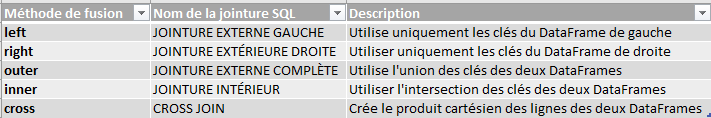

In [ ]:
left = pd.DataFrame({"key1": ["K0", "K0", "K1", "K2"], "key2": ["K0", "K1", "K0", "K1"],
                     "A": ["A0", "A1", "A2", "A3"], "B": ["B0", "B1", "B2", "B3"]})
right = pd.DataFrame({"key1": ["K0", "K1", "K1", "K2"], "key2": ["K0", "K0", "K0", "K0"],
                      "C": ["C0", "C1", "C2", "C3"], "D": ["D0", "D1", "D2", "D3"]})
inner = pd.merge(left, right, on=["key1", "key2"], how="inner")
outer = pd.merge(left, right, on=["key1", "key2"], how="outer", indicator=True)
suffixed = pd.merge(left, right.rename(columns={"C": "A", "D": "B"}),
                    on=["key1", "key2"], suffixes=("_left", "_right"))
joined = left.set_index(["key1", "key2"]).join(right.set_index(["key1", "key2"]), how="outer")
print(inner.shape, outer["_merge"].value_counts().to_dict(), suffixed.columns.tolist(), joined.shape)

**`merge_asof`** = jointure **temporelle approchée** : pour chaque ligne de gauche, prend la ligne de droite la plus proche (`forward` / `backward` / `nearest`), avec `tolerance` optionnelle. Les clés doivent être **triées**. Incontournable pour aligner des séries à granularités différentes (capteurs, ticks de marché).

In [ ]:
ts_left = pd.DataFrame({
    "date": pd.to_datetime(["2022-01-01", "2022-01-02", "2022-01-03", "2022-01-04"]),
    "value_X": ["A", "B", "C", "D"],
}).sort_values("date")
ts_right = pd.DataFrame({
    "date": pd.to_datetime(["2021-12-31 23:59:50", "2022-01-02 00:00:10",
                            "2022-01-03 23:59:50", "2022-01-04 23:59:50"]),
    "value_Y": ["a", "b", "c", "d"],
}).sort_values("date")
asof_fwd = pd.merge_asof(ts_left, ts_right, on="date", direction="forward")
asof_bwd = pd.merge_asof(ts_left, ts_right, on="date", direction="backward")
asof_near = pd.merge_asof(ts_left, ts_right, on="date", direction="nearest")
asof_tol = pd.merge_asof(ts_left, ts_right, on="date", direction="nearest",
                         tolerance=pd.Timedelta(seconds=15))
print(asof_fwd["value_Y"].tolist(), asof_bwd["value_Y"].tolist(),
      asof_near["value_Y"].tolist(), asof_tol["value_Y"].tolist())

**Anti-join (MINUS / EXCEPT SQL)** : les lignes de gauche **absentes** de droite. Recette robuste : `merge(how="left", indicator=True)` puis filtre `_merge == "left_only"`.

In [ ]:
def anti_join(left_df: pd.DataFrame, right_df: pd.DataFrame, on: list[str]) -> pd.DataFrame:
    """Lignes de `left_df` absentes de `right_df` (= EXCEPT/MINUS SQL)."""
    merged = left_df.merge(right_df, on=on, how="left", indicator=True)
    return merged[merged["_merge"] == "left_only"].drop(columns="_merge")


m_left = pd.DataFrame({"Nom": ["Florian", "Thomas", "Nicolas", "Dorian"],
                       "age": [31, 29, 30, 30], "type": ["A", "B", "C", "D"]})
m_right = pd.DataFrame({"Nom": ["Nicolas", "Dorian"], "age": [30, 30], "type": ["C", "D"]})
print(anti_join(m_left, m_right, on=["Nom", "age", "type"]))

Sur les **colonnes** : intersection (`columns.intersection`) ou différence (`columns.difference`).

In [ ]:
cols_common = m_left[m_left.columns.intersection(m_right.columns)]   # colonnes communes
cols_only_left = m_left[m_left.columns.difference(m_right.columns)]  # colonnes propres à gauche
print(cols_common.columns.tolist(), cols_only_left.columns.tolist())

**Update / upsert** : remplacer les lignes existantes (identifiées par une clé) puis ajouter les nouvelles — composition d'un anti-join et d'un `concat`.

In [ ]:
def update_rows(base: pd.DataFrame, new_rows: pd.DataFrame, keys: list[str]) -> pd.DataFrame:
    """Remplace dans `base` les lignes dont les `keys` existent dans `new_rows`, puis ajoute."""
    kept = anti_join(base, new_rows[keys], on=keys)
    return pd.concat([kept, new_rows], ignore_index=True)


base = pd.DataFrame({"id": [1, 2, 3], "v": ["x", "y", "z"]})
upd = pd.DataFrame({"id": [2, 4], "v": ["Y", "w"]})
print(update_rows(base, upd, keys=["id"]))

**Doublons & tri** : `duplicated(cols, keep=False)` marque toutes les occurrences en double → garder les **uniques** ou au contraire les **dupliquées**. Tri par `sort_values` ; un ordre **non alphabétique** se code via `pd.Categorical(..., categories=[...])`. `drop_duplicates(keep=False)` supprime toute valeur apparaissant plus d'une fois.

In [ ]:
def keep_unique(frame: pd.DataFrame, cols: list[str]) -> pd.DataFrame:
    """Lignes dont la combinaison `cols` n'apparaît qu'une fois."""
    return frame[~frame.duplicated(cols, keep=False)]


def keep_duplicates(frame: pd.DataFrame, cols: list[str]) -> pd.DataFrame:
    """Lignes dont la combinaison `cols` apparaît plusieurs fois."""
    return frame[frame.duplicated(cols, keep=False)]


dft = pd.DataFrame({"Nom": ["Florian", "Thomas", "Nicolas", "Dorian", "Florian", "Thomas"],
                    "age": [31, 29, 30, 30, 31, 29], "type": ["A", "B", "C", "D", "C", "D"]})
print(keep_unique(dft, ["Nom", "age"]).shape, keep_duplicates(dft, ["Nom", "age"]).shape)
# Tri (ordre naturel puis ordre catégoriel personnalisé)
sorted_nat = dft.sort_values(["age", "Nom"])
dft["type"] = pd.Categorical(dft["type"], categories=["B", "D", "A", "C"])
sorted_cat = dft.sort_values(["age", "type"])
print(sorted_nat["Nom"].tolist()[:3], sorted_cat["type"].tolist()[:3])
print(dft.drop_duplicates(subset="Nom", keep=False).shape)   # supprime toute valeur dupliquée

## 11. apply / map

`Series.apply` applique une fonction **élément par élément** ; `Series.map(dict)` recode via un dictionnaire ; `DataFrame.apply(axis=1)` parcourt les lignes (souvent **lent** → préférer le vectorisé) ; `groupby(...).transform(fn)` standardise par groupe.

In [ ]:
df["who_len"] = df["who"].apply(len)                       # apply sur Série
df["sex_short"] = df["sex"].map({"male": "M", "female": "F"})  # map dict
df["is_child"] = (df["age"] < 18).fillna(False)            # vectorisé > apply(axis=1)
df["age_z"] = df.groupby("class", observed=True)["age"].transform(lambda s: (s - s.mean()) / s.std())
print(df[["who", "who_len", "sex", "sex_short", "is_child"]].head(2))

## 12. Recherche conditionnelle

Boîte à outils pour **créer/modifier des colonnes selon des conditions** :

- **`Series.where(cond, autre)`** : garde la valeur si `cond`, sinon `autre`.
- **`np.where(cond, a, b)`** : ternaire vectorisé.
- **`np.select(conds, choix, default)`** : multi-conditions.
- **`assign`** : ajoute plusieurs colonnes (dont des `lambda`) sans muter l'original.
- **`insert`** : colonne à une position précise.
- **`str.split(expand=True)`** / **`str.cat`** : éclater / recoller du texte.

In [ ]:
cond_df = pd.DataFrame({
    "Cat": ["A", "B", "A", "C", "B"],
    "Cat_Num": ["A-0", "B-0", "A-1", "C-1", "B-1"],
    "mes1": [0, 10, 20, 10, 0],
    "mes2": [10, 20, 10, 20, 10],
})
# Pandas where : garde la valeur si cond vraie, sinon remplace
cond_df["res_where"] = cond_df["mes1"].where(cond_df["mes2"] <= 15, cond_df["mes2"] + 5)
# NumPy where : ternaire vectorisé
cond_df["res_np_where"] = np.where(cond_df["mes2"] <= 15, cond_df["mes2"] - 2, cond_df["mes2"] + 2)
# NumPy select : multi-conditions
conditions = [(cond_df["Cat"] == "A") & (cond_df["mes1"] > 15),
              (cond_df["Cat"] == "B") & (cond_df["mes1"] < 15)]
cond_df["res_select"] = np.select(conditions, ["A>15", "B<15"], default="0")
# assign : plusieurs colonnes d'un coup
cond_df = cond_df.assign(
    CatBis=cond_df["Cat_Num"].str.split("-", expand=True)[0],
    res_sum=lambda x: x.mes1 + x.mes2,
)
# insert : colonne à une position précise
cond_df.insert(2, "Cat_Num_copy", cond_df["Cat_Num"].values)
# split : éclate une colonne en plusieurs
cond_df[["Cat_part", "Num_part"]] = cond_df["Cat_Num"].str.split("-", expand=True)
# cat : recolle deux colonnes texte
cond_df["recolle"] = cond_df["Cat_part"].str.cat(cond_df["Num_part"], sep="-")
print(cond_df[["Cat", "mes1", "mes2", "res_where", "res_np_where", "res_select", "recolle"]])

## 13. Remplissage conditionnel

Remplir une colonne par propagation **jusqu'à** une modalité particulière (logique séquentielle, non vectorisable trivialement).

In [ ]:
fc = pd.DataFrame({"ID": [1, None, None, 2, None, 3, None, None, None],
                   "Etat": ["A", "B", "A", "C", "B", "A", "B", "A", "C"]})
last_id = None
for i, row in fc.iterrows():
    if pd.notna(row["ID"]):
        last_id = row["ID"]
    elif row["Etat"] != "A":
        fc.at[i, "ID"] = last_id
print(fc["ID"].tolist())

Variante avec **borne de début (D)** et **borne de fin (F)** : on ne propage qu'entre les deux.

In [ ]:
fc2 = pd.DataFrame({"ID": [1, None, None, 1, None, 2, None, 2, 3, 3],
                    "Etat": ["D", "I", "I", "F", "I", "D", "I", "F", "D", "F"]})
current_id = None
for idx, row in fc2.iterrows():
    if row["Etat"] == "D":
        current_id = row["ID"]
    elif row["Etat"] == "F":
        current_id = None
    else:
        fc2.at[idx, "ID"] = current_id
print(fc2["ID"].tolist())

## 14. Pivot & reshape

**`pivot_table`** agrège (comme un TCD Excel / `GROUP BY ... PIVOT`). Les colonnes deviennent **multi-niveaux** → on les **aplatit** (`columns.map("|".join)`). Ci-dessous, exemple par `device_id` × `Cat`.

In [ ]:
dfy = pd.DataFrame({
    "device_id": ["A", "A", "B", "B", "C", "C", "C"],
    "Qte": [2, 3, 4, 5, 7, 8, 9],
    "Prix": [10, 11, 14, 15, 20, 21, 22],
    "Cat": ["x", "y", "y", "z", "x", np.nan, "x"],
})
piv = dfy.pivot_table(index="device_id", columns="Cat", values=["Prix", "Qte"], aggfunc="mean")
piv.columns = piv.columns.map("|".join)       # aplatit les colonnes multi-niveaux
piv = piv.reset_index()
print(piv)

Format **long** servant aux démos de pivot suivantes (notes d'élèves par école et matière).

In [ ]:
df_long = pd.DataFrame({
    "student": ["Andy", "Bernie", "Cindy", "Deb"] * 3,
    "school": ["Z", "Y", "Z", "Y"] * 3,
    "classe": (["english"] * 4) + (["math"] * 4) + (["physics"] * 4),
    "Note": [10, 12, 16, 20, 12, 15, 15, 20, 11, 13.5, 14, 20],
    "Appr": ["pa", "ok", "tb", "ex", "ok", "tb", "tb", "ex", "pa", "b", "b", "ex"],
})
print(df_long.head())

Variantes : pivot simple, **`margins=True`** (totaux marginaux), agrégations multiples, `fill_value`. Les captures ci-dessous illustrent les résultats obtenus (issues du notebook d'origine).

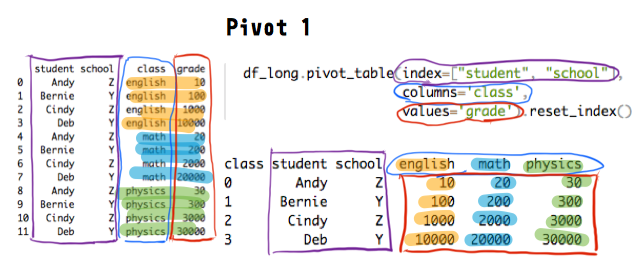

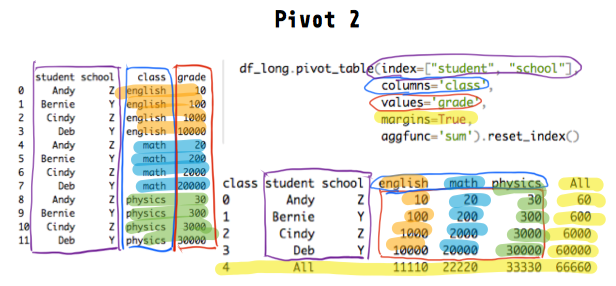

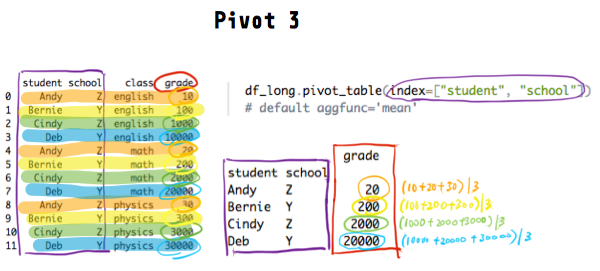

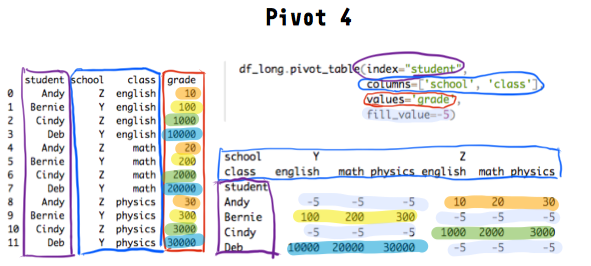

In [ ]:
piv_simple = df_long.pivot_table(index=["student", "school"], columns="classe", values="Note")
piv_margins = df_long.pivot_table(index=["student", "school"], columns="classe",
                                  values="Note", margins=True, aggfunc="sum")
piv_default = df_long.pivot_table(index=["student", "school"], values="Note")   # moyenne du numérique
piv_multi = df_long.pivot_table(index=["student", "school"], values="Note",
                                aggfunc=["min", "max", "count", "sum", "mean", "std"])
piv_fill = df_long.pivot_table(index="student", columns=["school", "classe"],
                               values="Note", fill_value=np.nan)
print(piv_simple.shape, piv_margins.shape, piv_default.shape, piv_multi.shape, piv_fill.shape)

**`melt`** passe du **large au long** (dénormalise) ; **`pivot`** fait l'inverse. C'est l'opération clé pour préparer des données à la visualisation (*tidy data*).

In [ ]:
wide = pd.DataFrame({"u": ["a", "b", "c"], "v": ["d", "e", "f"], "A": [1, 3, 5], "B": [2, 4, 6]})
melted = pd.melt(wide, id_vars=["u", "v"], value_vars=["A", "B"])
back = melted.pivot(index=["u", "v"], columns="variable", values="value").reset_index()
print(melted.shape, back.shape)

**`crosstab`** : raccourci pour un tableau de **comptage croisé** (ici, taux de survie par classe avec `normalize`).

In [ ]:
ct = pd.crosstab(df["class"], df["survived"], normalize="index")    # % survie par classe
print(ct.round(3))

**Extraire vers NumPy.** `df.lookup` a été **supprimé en pandas 2.0** ; on récupère un array via `.to_numpy()` et on reproduit le lookup par indexation positionnelle.

In [ ]:
mat = pd.DataFrame({"A": [1, 2, 3], "B": [4, 5, 6], "C": [7, 8, 9]}, index=["X", "Y", "Z"])


def lookup_values(frame: pd.DataFrame, row_labels: list, col_labels: list) -> np.ndarray:
    """Équivalent de l'ancien df.lookup : valeurs aux couples (ligne, colonne)."""
    rows = [frame.index.get_loc(r) for r in row_labels]
    cols = [frame.columns.get_loc(c) for c in col_labels]
    return frame.to_numpy()[rows, cols]


print(mat.to_numpy())                                  # tout le DataFrame en array
print(lookup_values(mat, ["X", "Y", "Z"], ["A", "B", "C"]))   # diagonale [1,5,9]

**Discrétiser** un continu : `cut` découpe en intervalles de **largeur régulière**, `qcut` en **quantiles** (effectifs ~égaux). Rappel : le $q$-ème quantile $Q(q)$ vérifie $P(X \le Q(q)) = q$.

In [ ]:
vals = np.array([1, 7, 5, 4, 6, 3])
cut = pd.cut(vals, bins=3, labels=["bad", "medium", "good"])         # bornes régulières
qcut = pd.qcut(vals, q=3, labels=["bad", "medium", "good"])          # quantiles (effectifs ~égaux)
print(list(cut), list(qcut))

**One-hot encoding** : `get_dummies` éclate une catégorielle en colonnes 0/1 ; `from_dummies` fait l'inverse.

In [ ]:
notes = pd.DataFrame({"Note": ["a", "a", "c", "b", "a", "b"]})
dummies = pd.get_dummies(notes["Note"], prefix="Note", prefix_sep="_")
undummied = pd.from_dummies(dummies, sep="_")
print(dummies.head(2))
print(undummied.head(2))

**`factorize`** encode des catégories en entiers (NaN → sentinelle `-1` avec `use_na_sentinel=True`) et renvoie aussi la table des modalités.

In [ ]:
fac = pd.DataFrame({"Note": ["a", "a", "c", np.nan, "b", "a", "b"]})
codes, uniques = pd.factorize(fac["Note"], use_na_sentinel=True)     # NaN -> -1
print(codes, list(uniques))

**Regrouper plusieurs colonnes large→long.** `pd.lreshape` (jamais documenté) a été **supprimé** → on utilise `pd.wide_to_long` (préfixes réguliers) ou `melt` (cas général).

In [ ]:
wdf = pd.DataFrame({"team": ["Red Sox", "Yankees"], "year1": [2006, 2007], "year2": [2008, 2009]})
long1 = pd.wide_to_long(wdf, stubnames="year", i="team", j="edition").reset_index()
# Cas multi-stub : melt manuel
multi = pd.DataFrame({"Prix_A": [514, 373], "Prix_B": [545, 326], "team": ["RS", "NY"]})
long2 = multi.melt(id_vars="team", var_name="prix_kind", value_name="prix")
print(long1)
print(long2)

**Dispersion.** L'écart-type empirique (non biaisé, $n-1$) :
$$\sigma = \sqrt{\frac{1}{n-1}\sum_{i=1}^{n}(x_i-\bar{x})^2}$$
L'**erreur standard de la moyenne** mesure la précision de $\bar{x}$ :
$$\mathrm{SEM} = \frac{\sigma}{\sqrt{n}}$$

In [ ]:
num = pd.DataFrame({"A": [1, 4, 7, 10, 13], "B": [2, 5, 8, 11, 14], "C": [3, 6, 9, 12, 15]})
print("std  :", num.std().round(3).tolist())     # écart-type (n-1 par défaut)
print("sem  :", num.sem().round(3).tolist())      # std / sqrt(n)

## 15. Sélection avancée & regex

On reconstruit un petit jeu **reproductible** de titres de conférences (le CSV d'origine ayant été perdu) pour illustrer la sélection et les regex.

In [ ]:
rng = np.random.default_rng(42)
acronyms = ["ISCAS", "INFOCOM", "VLDB", "WWW", "SIGGRAPH", "ICASSP"]
words = ["Data", "Deep", "Graph", "Signal", "Web", "Query", "Vision", "Network"]
titles = [f"{words[rng.integers(0, len(words))]} {words[rng.integers(0, len(words))]} study {k}"
          for k in range(30)]
conf = pd.DataFrame({
    "text": titles,
    "categories_name": [acronyms[rng.integers(0, len(acronyms))] for _ in range(30)],
})
conf["category_id"] = pd.factorize(conf["categories_name"])[0]
print(conf.shape, conf["categories_name"].unique().tolist())

Sélection **numérique** : `isin`, négation `~`, `between`, opérateurs `|` (OU) et `&` (ET) — chaque condition entre parenthèses.

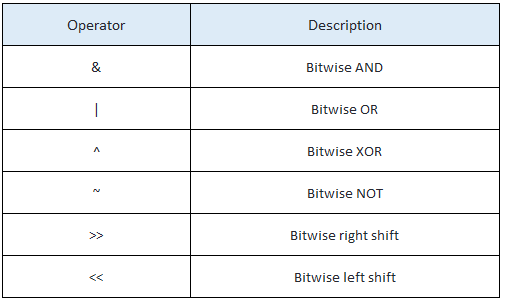

In [ ]:
print("isin       :", conf[conf["category_id"].isin([1, 2])].shape)
print("hors isin  :", conf[~conf["category_id"].isin([0, 3, 4])].shape)
print("between    :", conf[conf["category_id"].between(1, 2)].shape)
print("OU         :", conf[(conf["category_id"] == 1) | (conf["category_id"] == 2)].shape)
print("ET         :", conf[(conf["category_id"] > 0) & (conf["category_id"] < 3)].shape)

Sélection **catégorielle / textuelle** : `isin`, `str.contains` (sous-chaîne / regex), combinaisons.

In [ ]:
print("cat isin   :", conf[conf["categories_name"].isin(["ISCAS", "INFOCOM"])].shape)
print("contains   :", conf[conf["text"].str.contains("Data")].shape)
print("startswith+regex:", conf[conf["categories_name"].str.startswith("I") &
                                conf["text"].str.contains(r"\d+")].shape)

**Méthodes regex sur `.str`** (aide-mémoire ci-dessous) :

- **`match`** : correspondance **au début** de la chaîne.
- **`fullmatch`** : la chaîne **entière** doit correspondre.
- **`contains`** : correspondance **n'importe où** (`re.search`).
- **`extract`** : récupère les **groupes** capturés.

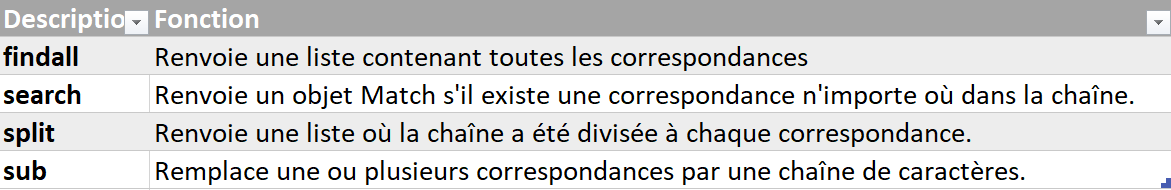

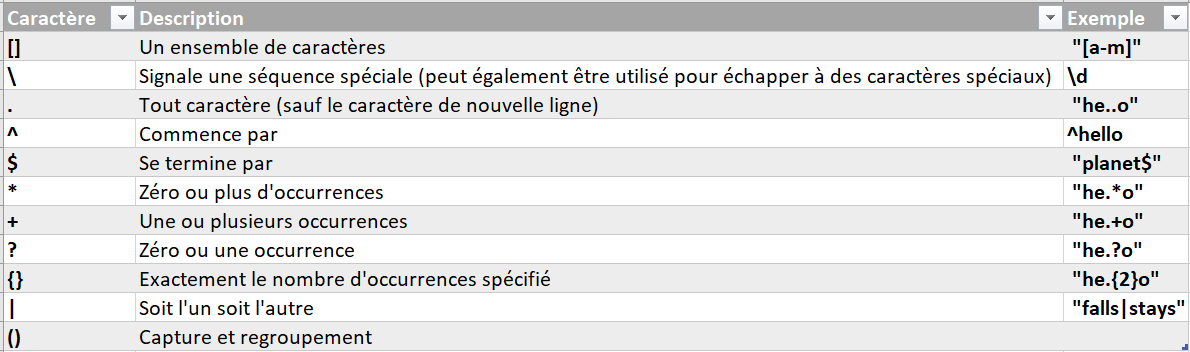

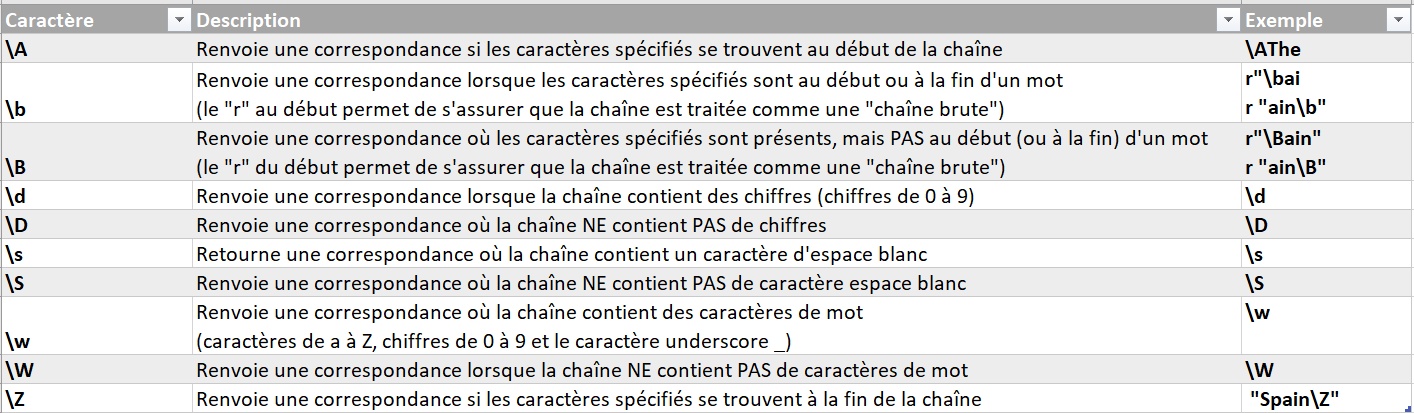

In [ ]:
# match : I suivi de 6 non-espaces (INFOCOM=7 ok, ISCAS=5 non)
print("match I+6  :", conf[conf["categories_name"].str.match(r"[I]\S{6}")].shape)
print("fullmatch  :", conf[conf["categories_name"].str.fullmatch(r"VLDB")].shape)
print("extract    :", conf["text"].str.extract(r"study (\d+)").dropna().shape)

Rechercher des **colonnes par nom** via une regex (utile sur des DataFrames larges aux colonnes nombreuses).

In [ ]:
def search_columns_by_name(frame: pd.DataFrame, pattern: str) -> pd.DataFrame:
    """Sous-DataFrame des colonnes dont le nom matche `pattern`."""
    cols = [c for c in frame.columns if re.search(pattern, c)]
    return frame[cols]


print(search_columns_by_name(conf, "cat").columns.tolist())

**`explode`** transforme une colonne de listes en **une ligne par élément** ; **`combine_first`** comble les NaN d'une série par une autre.

In [ ]:
exp = pd.DataFrame({"data": [[1, 2, 3], [4, 5], [6, 7, 8, 9]], "label": ["A", "B", "C"]})
exploded = exp.explode("data").reset_index(drop=True)               # une ligne par élément
cf = pd.DataFrame({"A": [None, 0, 12, 5, None], "B": [3, 4, 1, None, 11]})
combined = cf["A"].combine_first(cf["B"])                           # comble A par B
print(exploded.shape, combined.tolist())

**Conversion robuste string → datetime** : on teste plusieurs formats explicites puis on retombe sur l'inférence (`format="mixed"`). (`infer_datetime_format` a été **supprimé** en pandas 2.x — il est devenu le comportement par défaut.)

In [ ]:
def convertir_colonne_date(frame: pd.DataFrame, colonne: str) -> pd.DataFrame:
    """Convertit `colonne` en datetime en testant plusieurs formats, puis inférence."""
    frame = frame.copy()
    frame[colonne] = frame[colonne].str.replace(" ", "", regex=False)
    for fmt in ["%d.%m.%Y", "%Y-%m-%d", "%Y/%m/%d", "%d/%m/%Y", "%m-%d-%Y"]:
        try:
            frame[colonne] = pd.to_datetime(frame[colonne], format=fmt)
            return frame
        except (ValueError, TypeError):
            continue
    frame[colonne] = pd.to_datetime(frame[colonne], format="mixed", errors="raise")
    return frame


dates = pd.DataFrame({"d": ["2023-06-20", "2023-07-01", "2023-12-31"]})
print(convertir_colonne_date(dates, "d").dtypes.iloc[0])

## 16. Affichage & alternatives 2026

Pour un **rendu riche**, `DataFrame.style` formate et colore (export HTML possible). L'affichage interactif de Colab (`data_table`) n'existe pas hors Colab ; en 2026 les alternatives portables sont **`itables`** (DataTables.js) et **`great_tables`** (tables de publication).

In [ ]:
styled = (df[["class", "age", "fare"]].head()
          .style.format({"age": "{:.0f}", "fare": "{:.2f}"})
          .background_gradient(subset=["fare"], cmap="Blues"))
html = styled.to_html()      # exportable ; itables/great_tables = alternatives interactives 2026
print("HTML stylé généré:", len(html), "caractères")

**Pandas 2.x → 3.0.** Les **dtypes nullable** (`Int64`, `Float64`) portent les manquants **sans cast en float**. Le **backend PyArrow** (`dtype_backend="pyarrow"`) donne des colonnes columnar zéro-copie, et pandas 3.0 fait du **`str` Arrow** le type texte par défaut (5–10× plus rapide, ~50 % de mémoire en moins). La **Copy-on-Write** (par défaut en 3.0) supprime les pièges de modification de vue.

In [ ]:
nullable_int = pd.Series([1, 2, None], dtype="Int64")    # entier nullable (NaN sans cast float)
nullable_age = df["age"].astype("Float64")               # float nullable
# df_arrow = pd.read_csv("f.csv", dtype_backend="pyarrow")  # colonnes Arrow zéro-copie
print("Int64 nullable:", nullable_int.tolist(),
      "| NaN dans age:", int(nullable_age.isna().sum()))

**Polars** (Rust, *lazy*, multi-thread) est l'alternative montante : 5–30× plus rapide sur gros volumes, mode *streaming* > RAM, API stricte. On peut convertir depuis pandas (`pl.from_pandas`) et exprimer un *query plan* optimisé avant exécution (`.collect()`).

**Quand basculer** : fichiers > 100 Mo, latence critique, pas besoin de l'écosystème pandas.

In [ ]:
import polars as pl

pl_df = pl.from_pandas(df[["class", "age", "fare"]].dropna())
pl_res = (
    pl_df.lazy()
    .filter(pl.col("age") > 18)
    .group_by("class")
    .agg(pl.col("fare").mean().alias("mean_fare"), pl.len().alias("n"))
    .sort("n", descending=True)
    .collect()
)
print(pl_res)

print("\n=== NOTEBOOK SANDBOX OK ===")

## 17. Sources

- [Documentation pandas](https://pandas.pydata.org/docs/) — [What's new in 3.0](https://pandas.pydata.org/docs/whatsnew/v3.0.0.html)
- [Effective Pandas — Matt Harrison](https://store.metasnake.com/effective-pandas-book)
- [Modern Pandas — Tom Augspurger](https://tomaugspurger.net/posts/modern-1-intro/)
- [Documentation Polars](https://docs.pola.rs/)
- Notebooks liés : `Structure_Python`, `Structures_L_T_D_Cheat_Sheet`, `Structures_Preprocessing`, `Structure_BDD_DataFrame`.